# Chapter 13: Exotic Options

This atlas follows the lecture sequence and uses deterministic financial data so
that every code module can run without an internet connection.

## Learning map

1. Path-independent and path-dependent contracts
2. Asian average-price options
3. Barrier options
4. Chooser options
5. Monte Carlo comparison of exotic payoffs

**Code availability:** Yes. Every code cell imports its own dependencies,
contains Chinese exam-oriented comments, and produces an interpretable result.

## How to Study This Chapter

- **First pass:** Read the concept and formula sections without running code.
- **Second pass:** Predict the output and fill in the commented key lines before execution.
- **Third pass:** Run each module independently and explain the result in one sentence.
- **Final review:** Compare related methods and identify when each method should or should not be used.

## Chapter Checklist

- Can I define every variable and state its unit?
- Can I reproduce the main formula or workflow without looking?
- Can I identify the code lines most likely to appear as blanks?
- Can I interpret the output economically or statistically?
- Can I name at least one common implementation error?


## 13.1 Exotic Option Map

- **Asian option:** payoff depends on an average price.
- **Barrier option:** activation or cancellation depends on whether a barrier is crossed.
- **Lookback option:** payoff depends on a path maximum or minimum.
- **Compound option:** the underlying asset is another option.
- **Chooser option:** the holder later chooses whether the contract becomes a call or put.

Path dependence determines whether the full simulated price path must be stored.


## 13.2 Asian Average-Price Call

An arithmetic-average Asian call pays max(average path price - strike, 0), reducing sensitivity to a single terminal observation.


### Structured Review

- **Purpose:** State what the code calculates and why the quantity matters in finance.
- **Inputs:** Identify the required data, parameter units, and expected data type.
- **Process:** Follow the transformation in execution order rather than reading only the final line.
- **Output:** Connect the printed value to an economic or statistical interpretation.

### Exam Focus

- Identify the lines most likely to be removed in a code-completion question.
- Trace dimensions, indices, and units through each intermediate variable.
- Use a small numerical example to check the direction and scale of the answer.

### Common Mistakes

- Reusing a variable with a different meaning.
- Depending on a previous notebook cell for an import or intermediate object.
- Reporting a number without explaining its financial meaning.


In [1]:
import numpy as np

S0, K, r, sigma, T = 40, 40, 0.05, 0.20, 1.0
n_paths, n_steps = 50_000, 50
dt = T / n_steps
rng = np.random.default_rng(1302)

shocks = rng.standard_normal((n_paths, n_steps))
increments = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * shocks
paths = S0 * np.exp(np.cumsum(increments, axis=1))

# 亚洲期权使用路径平均价格，而普通欧式期权只使用最后价格
average_prices = paths.mean(axis=1)
asian_payoffs = np.maximum(average_prices - K, 0)
european_payoffs = np.maximum(paths[:, -1] - K, 0)

asian_price = np.exp(-r * T) * asian_payoffs.mean()
european_price = np.exp(-r * T) * european_payoffs.mean()
print("Asian call =", round(float(asian_price), 4))
print("European call =", round(float(european_price), 4))


Asian call = 2.3555
European call = 4.1547


**Result interpretation.** Averaging dampens extremes, so this Asian call is typically cheaper than the corresponding European call.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.


## 13.3 Up-and-Out Barrier Call

An up-and-out call becomes worthless if the stock price reaches or exceeds the barrier before maturity.


### Structured Review

- **Purpose:** State what the code calculates and why the quantity matters in finance.
- **Inputs:** Identify the required data, parameter units, and expected data type.
- **Process:** Follow the transformation in execution order rather than reading only the final line.
- **Output:** Connect the printed value to an economic or statistical interpretation.

### Exam Focus

- Identify the lines most likely to be removed in a code-completion question.
- Trace dimensions, indices, and units through each intermediate variable.
- Use a small numerical example to check the direction and scale of the answer.

### Common Mistakes

- Reusing a variable with a different meaning.
- Depending on a previous notebook cell for an import or intermediate object.
- Reporting a number without explaining its financial meaning.


In [2]:
import numpy as np

S0, K, barrier, r, sigma, T = 40, 40, 50, 0.05, 0.20, 1.0
n_paths, n_steps = 60_000, 100
dt = T / n_steps
rng = np.random.default_rng(1303)

shocks = rng.standard_normal((n_paths, n_steps))
increments = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * shocks
paths = S0 * np.exp(np.cumsum(increments, axis=1))

# 任一时点触及 barrier，knocked_out 就为 True
knocked_out = np.max(paths, axis=1) >= barrier
vanilla_payoffs = np.maximum(paths[:, -1] - K, 0)
barrier_payoffs = np.where(knocked_out, 0, vanilla_payoffs)

barrier_price = np.exp(-r * T) * barrier_payoffs.mean()
vanilla_price = np.exp(-r * T) * vanilla_payoffs.mean()
print("Knockout frequency =", round(float(knocked_out.mean()), 4))
print("Up-and-out call =", round(float(barrier_price), 4))
print("Vanilla call =", round(float(vanilla_price), 4))


Knockout frequency = 0.2841
Up-and-out call = 0.9977
Vanilla call = 4.1668


**Result interpretation.** The knockout feature removes valuable payoff scenarios, making the barrier call cheaper than the vanilla call.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.


## 13.4 Simple Chooser Option

At the choice date, the holder selects the more valuable remaining European call or put.


### Structured Review

- **Market inputs:** Identify spot price, strike, maturity, risk-free rate, volatility, and option premium.
- **Intermediate variables:** Compute `d1` before `d2`; both depend on consistent annualized inputs.
- **Distribution functions:** Distinguish the normal PDF from the normal CDF.
- **Sensitivity:** Interpret the result as a price or derivative with respect to an input.

### Exam Focus

- Reproduce the `d1` and `d2` sequence.
- Select `cdf` for option probabilities and `pdf` for Gamma.
- Check whether the formula is for a call, put, Delta, or Gamma.

### Common Mistakes

- Reversing spot and strike in the logarithm.
- Omitting the square root of maturity.
- Using percentage volatility such as `20` instead of decimal volatility `0.20`.


In [3]:
import numpy as np
from scipy.stats import norm

def option_values(S, K, remaining_time, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * remaining_time) / (sigma * np.sqrt(remaining_time))
    d2 = d1 - sigma * np.sqrt(remaining_time)
    call = S * norm.cdf(d1) - K * np.exp(-r * remaining_time) * norm.cdf(d2)
    put = K * np.exp(-r * remaining_time) * norm.cdf(-d2) - S * norm.cdf(-d1)
    return call, put

S0, K, r, sigma, maturity, choice_time = 40, 40, 0.05, 0.20, 1.0, 0.25
rng = np.random.default_rng(1304)
n_paths = 100_000

# 先模拟到选择时点，再比较剩余 call 与 put 的价值
z = rng.standard_normal(n_paths)
S_choice = S0 * np.exp((r - 0.5 * sigma**2) * choice_time + sigma * np.sqrt(choice_time) * z)
call, put = option_values(S_choice, K, maturity - choice_time, r, sigma)
chooser_price = np.exp(-r * choice_time) * np.maximum(call, put).mean()

print("Chooser option price =", round(float(chooser_price), 4))
print("Call chosen frequency =", round(float((call >= put).mean()), 4))


Chooser option price = 4.9461
Call chosen frequency = 0.6746


**Result interpretation.** The right to choose adds flexibility, so a chooser option is worth more than either fixed choice alone at inception.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.


## 13.5 Path-Dependence Comparison

Using common random numbers makes payoff differences easier to attribute to contract design rather than simulation noise.


### Structured Review

- **Purpose:** State what the code calculates and why the quantity matters in finance.
- **Inputs:** Identify the required data, parameter units, and expected data type.
- **Process:** Follow the transformation in execution order rather than reading only the final line.
- **Output:** Connect the printed value to an economic or statistical interpretation.

### Exam Focus

- Identify the lines most likely to be removed in a code-completion question.
- Trace dimensions, indices, and units through each intermediate variable.
- Use a small numerical example to check the direction and scale of the answer.

### Common Mistakes

- Reusing a variable with a different meaning.
- Depending on a previous notebook cell for an import or intermediate object.
- Reporting a number without explaining its financial meaning.


In [4]:
import numpy as np

S0, K, barrier, r, sigma, T = 40, 40, 50, 0.05, 0.20, 1.0
n_paths, n_steps = 30_000, 50
dt = T / n_steps
rng = np.random.default_rng(1305)

shocks = rng.standard_normal((n_paths, n_steps))
paths = S0 * np.exp(np.cumsum((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * shocks, axis=1))
discount = np.exp(-r * T)

european = discount * np.maximum(paths[:, -1] - K, 0).mean()
asian = discount * np.maximum(paths.mean(axis=1) - K, 0).mean()
barrier_payoff = np.where(paths.max(axis=1) >= barrier, 0, np.maximum(paths[:, -1] - K, 0))
barrier_call = discount * barrier_payoff.mean()

print("European =", round(float(european), 4))
print("Asian =", round(float(asian), 4))
print("Up-and-out =", round(float(barrier_call), 4))


European = 4.1536
Asian = 2.326
Up-and-out = 1.0501


**Result interpretation.** All three contracts share the same simulated paths, revealing how averaging and knockout clauses alter value.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.

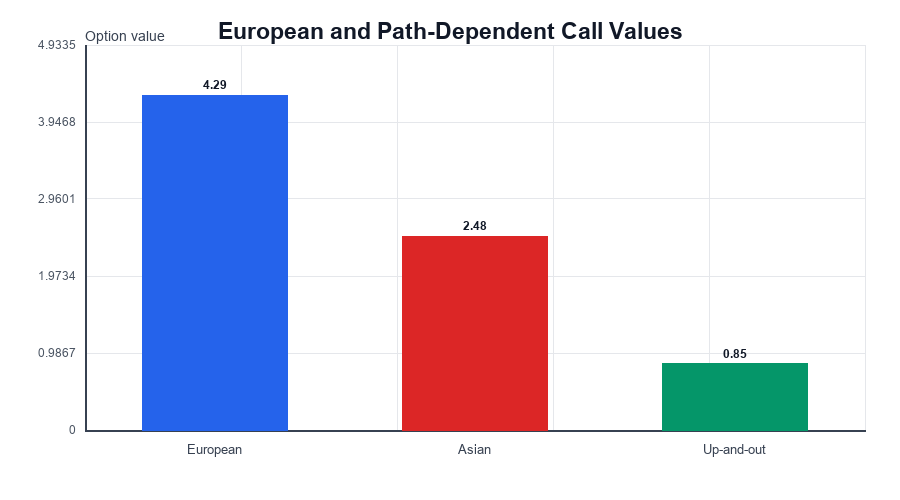
